<div style="
    background: linear-gradient(135deg, #2D1E2F 0%, #5A2A5E 45%, #2C6E8F 100%);
    padding: 34px;
    border-radius: 14px;
    margin: 10px 0 20px 0;
    box-shadow: 0 10px 26px rgba(45,30,47,0.34);
    border: 1px solid rgba(255,255,255,0.12);
">
    <h1 style="
        color: #ffffff;
        margin: 0;
        text-align: center;
        font-size: 34px;
        font-weight: 300;
        letter-spacing: 2px;
    ">PHY-3500 · Notebook 03</h1>
    <p style="
        color: rgba(255,255,255,0.92);
        margin: 10px 0 0 0;
        text-align: center;
        font-size: 18px;
        letter-spacing: 0.5px;
    ">Autoencodeur MLP pour réduction de dimension spectrale</p>
</div>

<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.14), rgba(44,110,143,0.12));
    border: 1px solid rgba(90,42,94,0.30);
    border-left: 6px solid #5A2A5E;
    border-radius: 10px;
    padding: 18px 20px;
    margin: 14px 0;
">
<strong>Auteur :</strong> Alex Baker<br>
<strong>Cours :</strong> PHY-3500 Physique numérique H26 - Université Laval<br>
<strong>Prérequis :</strong> Notebook 01 exécuté (features + PCAAnalyzer disponibles) ; Notebook 02 recommandé pour la synthèse comparative (UMAP/t-SNE)
</div>

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.14), rgba(45,30,47,0.14));
    border: 1px solid rgba(44,110,143,0.30);
    border-radius: 10px;
    padding: 18px 20px;
    margin: 14px 0;
">
<h3 style="margin: 0 0 10px 0; color: #5A2A5E;">Objectifs</h3>
<ol style="margin: 0; padding-left: 20px; line-height: 1.6;">
  <li>Entraîner un autoencodeur MLP sur les features spectrales LAMOST DR5.</li>
  <li>Explorer l’espace latent 2D et le comparer à PCA et UMAP.</li>
  <li>Comparer les performances de reconstruction avec PCA.</li>
  <li>Tester la continuité de l’espace latent par interpolation.</li>
  <li>Produire une synthèse comparative des méthodes.</li>
</ol>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 10px;
    padding: 12px 14px;
    margin-top: 10px;
">
<strong>Positionnement scientifique :</strong> ce notebook évalue une réduction de dimension non linéaire paramétrique (autoencodeur) et la confronte à deux baselines non supervisées (PCA, UMAP).
</div>

<a id="toc"></a>

## Table des matières

<div style="display: grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap: 12px; margin: 14px 0 22px 0;">

  <div style="background: linear-gradient(135deg, #5A2A5E, #2C6E8F); padding: 14px; border-radius: 10px;">
    <a href="#setup" style="color: white; text-decoration: none;"><strong>0. Imports et configuration</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#data" style="color: white; text-decoration: none;"><strong>1. Chargement des données</strong></a>
  </div>

  <div style="background: linear-gradient(135deg, #5A2A5E, #3D405B); padding: 14px; border-radius: 10px;">
    <a href="#arch" style="color: white; text-decoration: none;"><strong>2. Architecture et entraînement</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3D405B, #2C6E8F); padding: 14px; border-radius: 10px;">
    <a href="#ae3d" style="color: white; text-decoration: none;"><strong>2.1 Autoencodeur z=3</strong></a>
  </div>

  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#latent" style="color: white; text-decoration: none;"><strong>3. Espace latent 2D</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #5A2A5E, #3D405B); padding: 14px; border-radius: 10px;">
    <a href="#latent-zoom" style="color: white; text-decoration: none;"><strong>3.1 Espace latent zoomé</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3D405B, #2C6E8F); padding: 14px; border-radius: 10px;">
    <a href="#latent-kde" style="color: white; text-decoration: none;"><strong>3.2 Carte de densité KDE</strong></a>
  </div>

  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#recon" style="color: white; text-decoration: none;"><strong>4. Qualité de reconstruction</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #5A2A5E, #3D405B); padding: 14px; border-radius: 10px;">
    <a href="#recon-by-type" style="color: white; text-decoration: none;"><strong>4.2 Profil par type spectral</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3D405B, #2C6E8F); padding: 14px; border-radius: 10px;">
    <a href="#recon-compare" style="color: white; text-decoration: none;"><strong>4.3 Comparaison AE vs PCA</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#recon-error-class" style="color: white; text-decoration: none;"><strong>4.4 Erreurs par classe</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #5A2A5E, #3D405B); padding: 14px; border-radius: 10px;">
    <a href="#recon-family" style="color: white; text-decoration: none;"><strong>4.5 Erreur par famille spectro</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3D405B, #2C6E8F); padding: 14px; border-radius: 10px;">
    <a href="#recon-logscale" style="color: white; text-decoration: none;"><strong>4.6 Erreurs (échelle log)</strong></a>
  </div>

  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#interp" style="color: white; text-decoration: none;"><strong>5. Continuité latente</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #5A2A5E, #3D405B); padding: 14px; border-radius: 10px;">
    <a href="#arithmetic" style="color: white; text-decoration: none;"><strong>5.1 Arithmetic latente</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3D405B, #2C6E8F); padding: 14px; border-radius: 10px;">
    <a href="#anim" style="color: white; text-decoration: none;"><strong>5.2 Interpolation animée</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#anim-slider" style="color: white; text-decoration: none;"><strong>5.2.1 Slider interactif</strong></a>
  </div>

  <div style="background: linear-gradient(135deg, #5A2A5E, #3D405B); padding: 14px; border-radius: 10px;">
    <a href="#synthesis" style="color: white; text-decoration: none;"><strong>6. Synthèse comparative</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #3D405B, #2C6E8F); padding: 14px; border-radius: 10px;">
    <a href="#inference" style="color: white; text-decoration: none;"><strong>6.1 Inférence candidat</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#synthesis-grid" style="color: white; text-decoration: none;"><strong>6.2 Figure de synthèse</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #5A2A5E, #3D405B); padding: 14px; border-radius: 10px;">
    <a href="#synthesis-table" style="color: white; text-decoration: none;"><strong>6.3 Tableau comparatif</strong></a>
  </div>

  <div style="background: linear-gradient(135deg, #2C6E8F, #5A2A5E); padding: 14px; border-radius: 10px;">
    <a href="#save" style="color: white; text-decoration: none;"><strong>7. Sauvegarde des sorties</strong></a>
  </div>
  <div style="background: linear-gradient(135deg, #5A2A5E, #2D1E2F); padding: 14px; border-radius: 10px;">
    <a href="#conclusion" style="color: white; text-decoration: none;"><strong>Conclusion et références</strong></a>
  </div>

</div>

<a id="setup"></a>

<div style="background: linear-gradient(135deg, #5A2A5E 0%, #2C6E8F 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(90,42,94,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">0 · Imports et configuration</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 0 0 10px 0;
">
Cette cellule fixe l’environnement d’exécution, les chemins d’artefacts et la graine aléatoire. C’est la base de la reproductibilité expérimentale du notebook.
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #5A2A5E; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import spearmanr

# ── Environnement projet ───────────────────────────────────────────────────
sys.path.insert(0, str(Path("../..").resolve() / "src"))

from utils import setup_project_env, latest_file

paths = setup_project_env(verbose=True)

# ── Chemins ────────────────────────────────────────────────────────────────
FEATURES_PATH = latest_file(paths["PROCESSED_DIR"], "features_*.csv")
if FEATURES_PATH is None:
    raise FileNotFoundError(
        "Aucun fichier features_*.csv trouvé dans data/reports/\n"
        "→ Lancer d'abord 00_master_pipeline.ipynb pour générer les features."
    )
FEATURES_PATH  = Path(FEATURES_PATH)
CATALOG_PATH   = Path(paths["CATALOG_DIR"]) / "master_catalog_gaia.csv"
FIGURES_ROOT   = Path(paths["REPORTS_DIR"]) / "figures" / "phy3500"
FIGURES_DIR    = FIGURES_ROOT / FEATURES_PATH.stem
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR     = Path(paths["REPORTS_DIR"]) / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nFeatures  : {FEATURES_PATH}")
print(f"Catalog   : {CATALOG_PATH}")
print(f"Figures   : {FIGURES_DIR}")
print(f"Models    : {MODELS_DIR}")

# ── Imports dimred ─────────────────────────────────────────────────────────
from dimred import DimRedDataLoader, PCAAnalyzer, DimRedVisualizer
from dimred.autoencoder import SpectralAutoencoder

# ── Logging & reproductibilité ─────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n✓ Environnement prêt.")

[INFO] Project root detected: C:\Users\alexb\Documents\Projets\AstroSpectro
[INFO] 'src' directory added to sys.path.

Features  : C:\Users\alexb\Documents\Projets\AstroSpectro\data\processed\features_20260305T174836Z.csv
Catalog   : C:\Users\alexb\Documents\Projets\AstroSpectro\data\catalog\master_catalog_gaia.csv
Figures   : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z
Models    : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\models

✓ Environnement prêt.


<a id="data"></a>

<div style="background: linear-gradient(135deg, #2C6E8F 0%, #3D405B 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(44,110,143,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">1 · Chargement des données</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 0 0 10px 0;
">
Le pipeline de chargement est identique aux notebooks 01 et 02 pour garantir une comparaison rigoureuse entre méthodes.
</div>

Les variables d’entrée sont standardisées avant l’apprentissage :

$$
x'_j = \frac{x_j - \mu_j}{\sigma_j}
$$

Cette étape est essentielle car l’autoencodeur optimise une perte MSE sensible aux échelles des features.

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #3D405B; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [2]:
# Charge exactement le même jeu de données que NB01/NB02 pour garantir
# que les comparaisons AE vs PCA vs UMAP portent sur la même population.
loader = DimRedDataLoader(
    features_path=FEATURES_PATH,
    catalog_path=CATALOG_PATH,
    random_state=RANDOM_STATE,
)

X, y, meta = loader.load(
    mode="features",
    spectro_only=True,
    snr_min=10.0,
    scale=True,          # StandardScaler — obligatoire pour l'AE
    class_balance=False,
    classes=["STAR", "GALAXY", "QSO"],
)

# Ces objets servent dans tout le notebook : matrice X standardisée,
# étiquettes de classe et métadonnées astrophysiques Gaia/LAMOST.
feature_names = loader.get_feature_names()
input_dim     = X.shape[1]

print(f"\nDonnées chargées :")
print(f"  X         : {X.shape}")
print(f"  y         : {y.shape} | classes = {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"  meta      : {meta.shape}")
print(f"  input_dim : {input_dim}")

INFO | dimred.data_loader | Features chargées : features_20260305T174836Z.csv — 313 colonnes
INFO | dimred.data_loader | Catalog Gaia chargé : 134998 objets
INFO | dimred.data_loader | Merge features ∩ catalog : 99999 lignes
INFO | dimred.data_loader | Filtre SNR (snr_r >= 10.0) : 99999 → 53134 lignes
INFO | dimred.data_loader | Filtre classes ['STAR', 'GALAXY', 'QSO'] : 52428 lignes restantes
INFO | dimred.data_loader | Mode spectro_only=True : exclusion SNR + instrumentaux + Gaia photom.
INFO | dimred.data_loader | 183 features sélectionnées (spectro_only=True)
INFO | dimred.data_loader | Suppression NaN résiduel : 52428 → 43019 lignes
INFO | dimred.data_loader | Données prêtes : X=(43019, 183) | classes={'GALAXY': np.int64(56), 'QSO': np.int64(7), 'STAR': np.int64(42956)} | features=183



Données chargées :
  X         : (43019, 183)
  y         : (43019,) | classes = {'GALAXY': np.int64(56), 'QSO': np.int64(7), 'STAR': np.int64(42956)}
  meta      : (43019, 25)
  input_dim : 183


In [3]:
# Chargement du PCAAnalyzer sauvegardé (depuis notebook 01)
# ── Résilient à 3 cas : absent | incompatible | valide ────────────────────
pca_model_path = MODELS_DIR / "pca_analyzer.joblib"
_pca_loaded    = False

if pca_model_path.exists():
    try:
        pca = PCAAnalyzer.load(str(pca_model_path))

        # Vérification de compatibilité dimensionnelle
        n_expected = getattr(pca.sklearn_pca, "n_features_in_", None)
        if n_expected is not None and n_expected != X.shape[1]:
            raise ValueError(
                f"Dimensions incompatibles : modèle entraîné sur {n_expected} features, "
                f"X courant a {X.shape[1]} features (spectro_only a changé le nombre de features)."
            )

        scores_pca = pca.transform(X)
        _pca_loaded = True
        print(f"✓ PCAAnalyzer chargé ({pca.sklearn_pca.n_components_} composantes | "
              f"{X.shape[1]} features)")
        print(f"  scores_pca : {scores_pca.shape}")

    except Exception as e:
        print(f"⚠  PCAAnalyzer incompatible → réentraînement")
        print(f"   Raison : {e}")

if not _pca_loaded:
    print("▲  Entraînement PCAAnalyzer sur X courant...")
    pca = PCAAnalyzer(n_components=50, random_state=RANDOM_STATE)
    scores_pca = pca.fit_transform(X, feature_names=feature_names)
    pca.save(str(pca_model_path))
    print(f"✓  PCAAnalyzer entraîné et sauvegardé ({X.shape[1]} features → {scores_pca.shape[1]} PCs)")

n_pcs_95 = pca.n_components_for_variance(0.95)
print(f"  95% variance → {n_pcs_95} composantes PCA")

INFO | dimred.pca_analyzer | 95% variance → 51 composantes (sur 50)


✓ PCAAnalyzer chargé (50 composantes | 183 features)
  scores_pca : (43019, 50)
  95% variance → 51 composantes PCA


<a id="arch"></a>

<div style="background: linear-gradient(135deg, #3D405B 0%, #5A2A5E 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(61,64,91,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">2 · Architecture et entraînement de l’autoencodeur</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #5A2A5E;
    border-radius: 10px;
    padding: 14px 16px;
    margin-bottom: 10px;
">
<strong>Architecture choisie :</strong> X(D) -> 256 -> 128 -> 64 -> z(2) -> 64 -> 128 -> 256 -> Xhat(D)<br>
<strong>Activation :</strong> ReLU + BatchNorm + Dropout(0.1)<br>
<strong>Loss :</strong> MSE<br>
<strong>Optimisation :</strong> Adam + ReduceLROnPlateau + early stopping
</div>

Objectif d’apprentissage (forme simplifiée) :

$$
\mathcal{L}(\theta)=\frac{1}{N}\sum_{i=1}^N\|x_i-\hat x_i\|_2^2 + \lambda\|\theta\|_2^2
$$

où :
- le premier terme force la fidélité de reconstruction ;
- le second (weight decay) régularise les paramètres pour limiter le surapprentissage.

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin-bottom: 10px;
">
Le choix de z=2 est volontaire : il impose une compression sévère pour comparer directement Autoencodeur, PCA (PC1/PC2) et UMAP sur un même plan 2D.
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #5A2A5E; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [4]:
# ── Construction du modèle ────────────────────────────────────────────────
ae = SpectralAutoencoder(
    input_dim=input_dim,
    latent_dim=2,               # 2D pour comparaison directe PCA / UMAP
    hidden_dims=[256, 128, 64],
    dropout=0.1,
)

print(ae)
print(f"\nDevice : {ae.device}")

# Compte des paramètres (info pour le rapport)
try:
    import torch
    n_params = sum(p.numel() for p in ae._model.parameters()
                   if p is not None and p.requires_grad)
    # Reconstruit _model pour le comptage avant fit()
except Exception:
    pass

INFO | dimred.autoencoder | SpectralAutoencoder initialisé | D=183 → z=2 | device=cpu


SpectralAutoencoder(183 → [256, 128, 64] → 2)

Device : cpu


In [5]:
# Vérifie si un modèle sauvegardé existe déjà
ae_model_path = MODELS_DIR / "ae_latent2.pt"

if ae_model_path.exists():
    print("✓ Modèle autoencodeur trouvé — chargement...")
    ae = SpectralAutoencoder.load(str(ae_model_path))
    history = ae.history_
    print(f"  fit_time : {ae.fit_time_:.1f}s")
    print(f"  best val_loss : {min(history['val_loss']):.6f}")
else:
    print("Entraînement de l'autoencodeur (latent_dim=2)...")
    history = ae.fit(
        X,
        epochs=200,
        lr=1e-3,
        batch_size=512,
        val_fraction=0.10,
        weight_decay=1e-5,
        lr_scheduler=True,
        early_stopping_patience=25,
        verbose=True,
    )
    ae.save(str(ae_model_path))
    print(f"\n✓ Modèle sauvegardé : {ae_model_path}")

print(f"\nEpochs effectuées : {len(history['train_loss'])}")
print(f"Best val_loss     : {min(history['val_loss']):.6f}")

INFO | dimred.autoencoder | SpectralAutoencoder initialisé | D=183 → z=2 | device=cpu
INFO | dimred.autoencoder | SpectralAutoencoder chargé depuis : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\models\ae_latent2.pt


✓ Modèle autoencodeur trouvé — chargement...
  fit_time : 228.2s
  best val_loss : 0.535405

Epochs effectuées : 200
Best val_loss     : 0.535405


<a id="ae3d"></a>

<div style="background: linear-gradient(135deg, #3D405B 0%, #5A2A5E 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(61,64,91,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">2.1 · Autoencodeur z=3 — un axe latent de plus</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #5A2A5E;
    border-radius: 10px;
    padding: 14px 16px;
    margin-bottom: 10px;
">
<p style="margin: 0 0 8px 0;">Le modèle z=2 compresse vers un plan bidimensionnel. On s'interroge ici : <strong>un troisième axe latent encode-t-il un paramètre physique indépendant</strong> (métallicité, gravité de surface) que les deux premiers n'ont pas capté ?</p>
<p style="margin: 0;">Cette question est directement comparable au UMAP 3D de NB02, où l'axe 3 corrélait faiblement avec log g (ρ=−0.21). L'AE, étant paramétrique et optimisé pour la reconstruction, pourrait trouver un troisième axe plus informatif.</p>
</div>

$$
f_\theta: \mathbb{R}^{183} \rightarrow \mathbb{R}^{3}, \quad z=f_\theta(x)
\qquad g_\phi: \mathbb{R}^{3} \rightarrow \mathbb{R}^{183}, \quad \hat x=g_\phi(z)
$$

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #5A2A5E; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [6]:
# Essaie d'abord de réutiliser un checkpoint z=3 pour éviter un réentraînement
# inutile. On vérifie explicitement la compatibilité de dimension d'entrée
# (input_dim) avant de le conserver.
ae3_model_path = MODELS_DIR / 'ae_latent3.pt'
_ae3_loaded = False
if ae3_model_path.exists():
    _tmp = SpectralAutoencoder.load(str(ae3_model_path))
    saved_dim3 = getattr(_tmp._model.encoder.net[0], 'in_features', None)
    if saved_dim3 == input_dim:
        ae3 = _tmp
        history3 = ae3.history_
        _ae3_loaded = True
        print(f'✓ Checkpoint ae_latent3.pt chargé | epochs={len(history3["train_loss"])} | best_val={min(history3["val_loss"]):.5f}')
    else:
        print(f'⚠  Checkpoint périmé ({saved_dim3} vs {input_dim}) → réentraînement.')
        ae3_model_path.unlink()

if not _ae3_loaded:
    # Même recette d'entraînement que z=2, seule la dimension latente change.
    ae3 = SpectralAutoencoder(input_dim=input_dim, latent_dim=3, hidden_dims=[256, 128, 64], dropout=0.1)
    history3 = ae3.fit(X, epochs=200, lr=1e-3, batch_size=512, val_fraction=0.10,
                       weight_decay=1e-5, lr_scheduler=True, early_stopping_patience=25, verbose=True)
    ae3.save(str(ae3_model_path))
    print(f'✓ Modèle sauvegardé : {ae3_model_path}')

# Encodage 3D pour examiner si un 3e axe porte une information physique nette.
Z_ae3 = ae3.encode(X)
print(f'Espace latent z=3 : {Z_ae3.shape}')

# Corrélations Spearman : lecture physique de chaque axe latent.
phys_z3 = [('teff_gspphot','T_eff'), ('logg_gspphot','log g'),
            ('mh_gspphot','[Fe/H]'), ('bp_rp','BP-RP')]
print('\nCorrélations Spearman — AE z=3 vs paramètres Gaia')
print(f'{"Paramètre":<12} {"Axe 1":>10} {"Axe 2":>10} {"Axe 3":>10}')
print('-' * 46)
for col, label in phys_z3:
    if col not in meta.columns: continue
    vals = meta[col].values.astype(float)
    valid = np.isfinite(vals)
    r1, _ = spearmanr(Z_ae3[valid, 0], vals[valid])
    r2, _ = spearmanr(Z_ae3[valid, 1], vals[valid])
    r3, _ = spearmanr(Z_ae3[valid, 2], vals[valid])
    print(f'{label:<12} {r1:>+10.3f} {r2:>+10.3f} {r3:>+10.3f}')

# Compare directement la reconstruction z=2 vs z=3 (gain relatif en %).
X_recon3 = ae3.reconstruct(X)
mse3 = float(np.mean((X - X_recon3) ** 2))
mse2_ref = float(np.mean((X - ae.reconstruct(X)) ** 2))
print(f'\nMSE z=2 : {mse2_ref:.5f} | MSE z=3 : {mse3:.5f} | Gain : {(mse2_ref-mse3)/mse2_ref*100:.1f}%')

INFO | dimred.autoencoder | SpectralAutoencoder initialisé | D=183 → z=3 | device=cpu
INFO | dimred.autoencoder | SpectralAutoencoder chargé depuis : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\models\ae_latent3.pt


✓ Checkpoint ae_latent3.pt chargé | epochs=200 | best_val=0.48750
Espace latent z=3 : (43019, 3)

Corrélations Spearman — AE z=3 vs paramètres Gaia
Paramètre         Axe 1      Axe 2      Axe 3
----------------------------------------------
T_eff            -0.560     +0.756     +0.292
log g            +0.433     -0.061     -0.212
[Fe/H]           +0.214     -0.537     -0.133
BP-RP            +0.368     -0.745     -0.064

MSE z=2 : 0.50230 | MSE z=3 : 0.44331 | Gain : 11.7%


<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #3D405B;
    border-radius: 10px;
    padding: 16px 18px;
    margin: 8px 0 14px 0;
">
<h4 style="margin: 0 0 10px 0; color: #3D405B;">Interprétation — AE z=3 vs UMAP 3D</h4>
<p style="margin: 0 0 8px 0;">Si l'axe 3 de l'AE corrèle plus fortement avec un paramètre physique que l'axe 3 UMAP (|ρ|=0.21 avec log g dans NB02), cela démontre l'avantage de l'approche paramétrique : l'AE est contraint par la reconstruction et découvre des axes plus informatifs que la projection topologique de UMAP.</p>
<p style="margin: 0;">Le gain de MSE (z=2 → z=3) est attendu mais doit être interprété avec prudence : plus de dimensions = meilleure reconstruction, mais aussi plus de paramètres et moins de contrainte de compression. L'intérêt scientifique réside dans l'<em>interprétabilité</em> du troisième axe, pas uniquement dans le gain de MSE.</p>
</div>

In [ ]:
# Trace les courbes train/val loss pour vérifier convergence, surapprentissage
# et effet de l'early stopping sur l'AE z=2.
viz = DimRedVisualizer(figsize=(12, 4), dpi=150, output_dir=FIGURES_DIR)

fig, axes = viz.plot_training_history(
    history,
    save_path=FIGURES_DIR / "ae_training_history.png",
)
plt.show()

<a id="latent"></a>

<div style="background: linear-gradient(135deg, #5A2A5E 0%, #2C6E8F 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(90,42,94,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">3 · Espace latent 2D - visualisation et interprétation physique</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 0 0 10px 0;
">
Les mêmes colorations physiques que dans PCA et UMAP sont utilisées pour comparer directement les géométries d’embedding.
</div>

Un encodeur apprend une application non linéaire :

$$
f_\theta: \mathbb{R}^{183} \rightarrow \mathbb{R}^{2}, \quad z=f_\theta(x)
$$

et le décodeur reconstruit :

$$
g_\phi: \mathbb{R}^{2} \rightarrow \mathbb{R}^{183}, \quad \hat x=g_\phi(z)
$$

L’objectif est de compresser l’information spectrale utile dans deux variables latentes tout en conservant une structure physiquement cohérente.

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #5A2A5E; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [7]:
# ── Encodage ──────────────────────────────────────────────────────────────
# Projection de tous les spectres dans le plan latent appris (z1, z2).
Z_ae = ae.encode(X)
print(f"Espace latent : {Z_ae.shape}")
print(f"  axe 1 : [{Z_ae[:,0].min():.2f}, {Z_ae[:,0].max():.2f}]")
print(f"  axe 2 : [{Z_ae[:,1].min():.2f}, {Z_ae[:,1].max():.2f}]")

Espace latent : (43019, 2)
  axe 1 : [-26.47, 58.48]
  axe 2 : [-36.32, 73.70]


In [ ]:
# ── Grille de visualisations ──────────────────────────────────────────────
# Même logique de colorations physiques que PCA/UMAP pour comparer
# directement la géométrie de l'embedding.
fig, axes = viz.plot_ae_embedding(
    Z_ae, meta, y,
    save_path=FIGURES_DIR / "ae_latent_grid.png",
)
plt.show()

<a id="latent-zoom"></a>

### 3.1 · Espace latent zoomé — population stellaire

La figure précédente a une échelle globale dominée par quelques **points extrêmes** (4 QSOs, certaines galaxies atypiques) que l'autoencodeur entraîné sur des étoiles ne peut pas reconstruire — il les repousse loin de la région stellaire dans l'espace latent. Cela illustre une propriété utile : l'AE agit implicitement comme un **détecteur d'anomalies**.

Pour visualiser la structure interne de la population stellaire, on zoome sur la région principale (percentiles 1–99).

In [ ]:
# Zoom robuste sur la population principale : les outliers extrêmes
# (QSOs/galaxies) n'écrasent plus la dynamique visuelle des étoiles.
fig, axes = viz.plot_latent_zoomed(
    Z_ae=Z_ae, y=y, meta=meta,
    save_path=FIGURES_DIR / 'ae_latent_grid_zoomed.png',
)
plt.show()

<a id="latent-kde"></a>

### 3.2 · Carte de densité KDE — populations stellaires dans l'espace latent

<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #5A2A5E;
    border-radius: 10px;
    padding: 12px 14px;
    margin-bottom: 10px;
">
Le scatter plot coloré par T_eff montre la <em>position</em> de chaque étoile. Cette figure montre la <em>densité</em> : où se concentrent les populations. Les crêtes de densité correspondent aux types spectraux dominants dans LAMOST DR5. Les iso-contours délimitent les régions où 68%, 95% et 99% des étoiles sont concentrées.
</div>

In [ ]:
# La carte KDE complète le scatter: elle rend lisibles les régions
# de forte concentration stellaire et leurs contours de densité.
fig, axes = viz.plot_latent_kde(
    Z_ae=Z_ae, y=y, meta=meta,
    save_path=FIGURES_DIR / 'ae_latent_kde.png',
)
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 12px 0;
">
<h4 style="margin: 0 0 8px 0; color: #2C6E8F;">Lecture scientifique — Topographie de l'espace latent</h4>
<p style="margin: 0 0 6px 0;">Les crêtes de densité révèlent la structure intrinsèque du dataset LAMOST DR5 : une <strong>crête principale</strong> correspondant à la séquence principale (naines F/G/K), des zones de <strong>faible densité</strong> aux extrêmes (étoiles M froides, étoiles A chaudes — moins représentées dans le catalogue), et des <strong>excursions</strong> au-delà du contour 99% signalant les objets atypiques.</p>
<p style="margin: 0;">La superposition T_eff / log g / [Fe/H] sur la même géométrie permet de vérifier que les axes latents encodent bien des informations physiques complémentaires et non redondantes.</p>
</div>

### Interprétation — Espace latent et détection d'anomalies

La version zoomée révèle la structure interne de la population stellaire :
- **Axe latent 2** encode principalement la **température** (ρ Spearman = -0.76 avec T_eff) — le gradient chaud/froid est clairement visible.
- **Axe latent 1** encode une combinaison de métallicité et de stade évolutif (ρ ≈ 0.27 avec [Fe/H]), mais de façon moins nette que PC1 de la PCA.

Les axes latents sont **arbitraires en orientation** (signe et ordre), contrairement aux composantes PCA ordonnées par variance décroissante. C'est une limitation fondamentale des autoencodeurs non supervisés.

**Propriété émergente — détection d'anomalies** : les quelques galaxies et QSOs sont repoussés à des coordonnées latentes extrêmes (jusqu'à y≈88 pour les QSOs). L'AE, entraîné quasi-exclusivement sur des étoiles, ne peut pas reconstruire les spectres non-stellaires → il les projette hors de la distribution apprise. Un seuil simple sur la distance à l'origine dans l'espace latent suffirait à les détecter sans supervision.

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.10), rgba(90,42,94,0.10));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 8px 0 14px 0;
">
<h4 style="margin: 0 0 8px 0; color: #2C6E8F;">Corrélations espace latent et paramètres physiques (Spearman)</h4>
Comparer ces corrélations avec PC1/PC2 permet d’évaluer ce que l’autoencodeur préserve (ou transforme) de la structure physique stellaire.
</div>

Le coefficient de Spearman mesure la monotonicité entre deux variables de rang :

$$
\rho_s = 1 - \frac{6\sum_i d_i^2}{n(n^2-1)}
$$

où $d_i$ est la différence entre les rangs de deux observations.

### Interprétation
- Une forte $|\rho_s|$ entre un axe latent et T_eff ou BP-RP indique une capture efficace d’un gradient astrophysique majeur.
- Une redistribution de l’information entre axe 1 et axe 2 est normale en non linéaire : les axes latents ne sont pas directement comparables aux composantes PCA.

In [8]:
# Compare quantitativement la sémantique des axes latents avec des
# paramètres physiques de référence (T_eff, log g, [Fe/H], couleur).
phys_cols   = ['teff_gspphot', 'logg_gspphot', 'mh_gspphot', 'bp_rp']
phys_labels = ['T_eff', 'log g', '[Fe/H]', 'G_BP-G_RP']

print('Corrélations Spearman : Espace latent AE ↔ Paramètres physiques')
print('-' * 60)
print(f'{"Paramètre":<15} {"Axe latent 1":>14} {"Axe latent 2":>14}')
print('-' * 60)
for col, lbl in zip(phys_cols, phys_labels):
    if col not in meta.columns: continue
    vals = meta[col].values.astype(float)
    valid = np.isfinite(vals)
    r1, _ = spearmanr(Z_ae[valid, 0], vals[valid])
    r2, _ = spearmanr(Z_ae[valid, 1], vals[valid])
    print(f'{lbl:<15} {r1:>+14.3f} {r2:>+14.3f}')
print('-' * 60)

# Point de comparaison direct avec la base linéaire (PC1/PC2).
print('\nRappel — PC1/PC2 (notebook 01) :')
corr_pca = pca.correlations_with_params(meta[phys_cols], scores=scores_pca, n_pcs=2)
print(corr_pca.round(3).to_string())

Corrélations Spearman : Espace latent AE ↔ Paramètres physiques
------------------------------------------------------------
Paramètre         Axe latent 1   Axe latent 2
------------------------------------------------------------
T_eff                   -0.246         +0.799
log g                   -0.263         -0.104
[Fe/H]                  +0.224         -0.546
G_BP-G_RP               +0.343         -0.761
------------------------------------------------------------

Rappel — PC1/PC2 (notebook 01) :
     teff_gspphot  logg_gspphot  mh_gspphot  bp_rp
PC1         0.831        -0.155      -0.548 -0.768
PC2         0.156         0.081      -0.082 -0.025


<a id="recon"></a>

<div style="background: linear-gradient(135deg, #2C6E8F 0%, #3D405B 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(44,110,143,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">4 · Qualité de reconstruction - autoencodeur vs PCA</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 0 0 10px 0;
">
<strong>4.1 Exemples de reconstruction</strong>
</div>

Pour chaque objet, l’erreur quadratique moyenne est :

$$
\mathrm{MSE}_i = \frac{1}{D}\sum_{j=1}^{D}(x_{ij}-\hat x_{ij})^2
$$

La comparaison AE vs PCA permet de mesurer le gain de non-linéarité à dimension fixée (2D), puis de situer ce gain face à une PCA plus riche (n composantes pour 95% de variance).

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #2C6E8F; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [9]:
# Première lecture macro : erreur globale de reconstruction selon la méthode
# et selon la capacité de la PCA (2 composantes vs seuil 95% variance).
X_recon = ae.reconstruct(X)

print(f"MSE globale autoencodeur (latent_dim=2) : {ae.reconstruction_mse(X):.5f}")
print(f"MSE globale PCA (n=2)                   : "
      f"{pca.reconstruction_error(X, n_components=2).mean():.5f}")
print(f"MSE globale PCA (n={n_pcs_95})                  : "
      f"{pca.reconstruction_error(X, n_components=n_pcs_95).mean():.5f}")

MSE globale autoencodeur (latent_dim=2) : 0.50230
MSE globale PCA (n=2)                   : 0.69627
MSE globale PCA (n=51)                  : 0.19624


In [ ]:
# Inspection qualitative de reconstructions individuelles :
# utile pour voir quelles familles de features sont bien reproduites.
fig, axes = viz.plot_ae_reconstruction(
    X, X_recon, feature_names,
    n_samples=5,
    y=y,
    save_path=FIGURES_DIR / "ae_reconstruction_examples.png",
)
plt.show()

<a id="recon-by-type"></a>

### 4.2 · Reconstruction originale vs reconstruite — profil par type spectral

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin-bottom: 10px;
">
Pour chaque type spectral (A, F, G, K, M), on calcule le profil moyen des <strong>features clés</strong> pour les spectres originaux et leurs versions reconstruites par l'AE. L'écart entre les deux courbes révèle où le modèle est fidèle et où il approxime — une validation visuelle de la qualité de reconstruction.
</div>

In [10]:
# Recalcule la reconstruction complète pour comparer des profils moyens
# originaux vs reconstruits par type spectral.
X_recon = ae.reconstruct(X)

# Charge de préférence les types prédits par XGBoost (NB02) pour une
# taxonomie plus riche; fallback robuste sur les labels LAMOST sinon.
_emb_path = Path(MODELS_DIR).parent / 'runs' / 'phy3500_umap_tsne' / 'phy3500_embeddings_latest.joblib'
_xgb_ok = False
if _emb_path.exists():
    _emb = joblib.load(str(_emb_path))
    if 'xgb_predictions' in _emb and _emb['xgb_predictions'] is not None:
        spectral_types = np.array(_emb['xgb_predictions'])
        _xgb_ok = True
        print(f'✓ Types XGBoost chargés : {dict(zip(*np.unique(spectral_types, return_counts=True)))}')

if not _xgb_ok:
    spectral_types = y  # fallback
    print('⚠  Fallback sur classe LAMOST')

fig, axes = viz.plot_ae_recon_by_spectral_type(
    X=X, X_recon=X_recon,
    spectral_types=spectral_types,
    feature_names=feature_names,
    save_path=FIGURES_DIR / 'ae_recon_by_spectral_type.png',
)
plt.show()

✓ Types XGBoost chargés : {np.str_('A'): np.int64(2540), np.str_('F'): np.int64(11163), np.str_('G'): np.int64(19742), np.str_('K'): np.int64(8437), np.str_('M'): np.int64(1038)}


NameError: name 'viz' is not defined

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 6px 0 12px 0;
">
<h4 style="margin: 0 0 8px 0;">Lecture par type spectral</h4>
<p style="margin: 0 0 6px 0;"><strong>Types A/F (chauds) :</strong> Hα et Hβ très positifs, Ca II faibles ou négatifs — l'AE devrait bien reconstruire car ces signatures sont fortes et cohérentes.</p>
<p style="margin: 0 0 6px 0;"><strong>Types G/K (solaires) :</strong> profil équilibré, signatures modérées sur tous les indices. Zone la plus représentée dans LAMOST → reconstruction la plus précise attendue.</p>
<p style="margin: 0;"><strong>Type M (froid) :</strong> TiO très fort, Balmer très faibles, Ca II modérés. L'AE est moins entraîné sur ces étoiles (sous-représentées) → résidus potentiellement plus grands sur TiO.</p>
</div>

<a id="recon-compare"></a>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-left: 5px solid #5A2A5E;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 8px 0;
">
<strong>4.3 Comparaison MSE autoencodeur vs PCA</strong>
</div>

In [ ]:
# Balaye plusieurs tailles de PCA pour situer l'AE z=2 sur une courbe
# erreur-vs-dimension (gain de non-linéarité à dimension fixée).
comparison_df = ae.compare_with_pca(
    X, pca,
    n_pcs_list=[1, 2, 3, 5, 8, 10, 15, 20, 30, 50],
)
print(comparison_df.to_string(index=False))

fig, ax = viz.plot_ae_vs_pca(
    comparison_df,
    save_path=FIGURES_DIR / "ae_vs_pca_mse.png",
)
plt.show()

### Interprétation — AE@2 ≈ PCA@10 : la valeur de la non-linéarité

C'est le résultat central de ce notebook :

| Méthode | Dimensions | MSE reconstruction |
|---------|-----------|-------------------|
| PCA     | 2         | 0.7317            |
| PCA     | 5         | 0.6290            |
| PCA     | 8         | 0.5722            |
| **AE**  | **2**     | **0.5411**        |
| PCA     | 10        | 0.5430            |
| PCA     | 15        | 0.4803            |

L'autoencodeur à **2 dimensions latentes** reconstruit les spectres aussi bien qu'une **PCA à 10 composantes**. Autrement dit, la non-linéarité permet d'encoder 5× plus d'information dans le même nombre de dimensions.

Cela s'explique physiquement : la séquence stellaire n'est pas un sous-espace euclidien — c'est une **variété courbée** dans l'espace des features. La PCA doit utiliser de nombreux axes linéaires pour approximer cette courbure, là où l'AE la capture directement.

<a id="recon-error-class"></a>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-left: 5px solid #5A2A5E;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 8px 0;
">
<strong>4.4 Distribution des erreurs par classe</strong>
</div>

In [ ]:
# Résumé tabulaire par classe: médianes et dispersion des erreurs.
summary = ae.reconstruction_summary(X, y=y)
print("\nErreurs de reconstruction par classe :")
print(summary.to_string(index=False))

# Distribution individuelle (une MSE par objet) pour voir recouvrement
# entre classes STAR / GALAXY / QSO.
mse_per = ae.reconstruction_mse(X, per_sample=True)

fig, ax = viz.plot_ae_error_distribution(
    mse_per, y,
    save_path=FIGURES_DIR / "ae_error_distribution.png",
)
plt.show()

<a id="recon-family"></a>

<div style="background: linear-gradient(135deg, #2C6E8F 0%, #3D405B 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(44,110,143,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">4.5 · Erreur de reconstruction par famille spectroscopique</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.10), rgba(61,64,91,0.10));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 12px 14px;
    margin-bottom: 10px;
">
<p style="margin: 0 0 8px 0;">La symétrie parfaite avec §4.1 de NB01 : au lieu de demander <em>quelle famille drive PC1</em>, on demande <em>quelle famille l'AE reconstruit-il le mieux</em>. Les familles avec les MSE les plus basses sont celles que le modèle a internalisées avec le plus de précision — ce sont les features les plus structurantes pour la reconstruction.</p>
<p style="margin: 0;"><strong>Hypothèse :</strong> Balmer et Ca II (forts et systématiques) → MSE basse. TiO et s-process (rares, seulement dans K/M et exotiques) → MSE élevée.</p>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #2C6E8F; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [ ]:
# Agrège les features en familles physiques (Balmer, Ca II, TiO, etc.)
# pour identifier où l'AE reconstruit le mieux / le moins bien.
X_recon = ae.reconstruct(X)

fig, axes = viz.plot_ae_error_by_family(
    X=X,
    X_recon=X_recon,
    feature_names=feature_names,
    pca_analyzer=pca,
    save_path=FIGURES_DIR / 'ae_recon_error_by_family.png',
)
plt.show()

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.10), rgba(61,64,91,0.10));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 12px 0;
">
<h4 style="margin: 0 0 8px 0; color: #2C6E8F;">Interprétation — Ce que l'AE apprend vraiment</h4>
<p style="margin: 0 0 6px 0;">Les familles avec une <strong>MSE basse</strong> sont celles que l'autoencodeur reconstruit fidèlement : il a appris à les prédire précisément depuis l'espace latent. Ce sont les features les plus <em>redondantes et structurées</em> dans le dataset.</p>
<p style="margin: 0 0 6px 0;">Les familles avec une <strong>MSE haute</strong> sont soit rares (s-process, présent seulement dans quelques % des étoiles), soit très variables d'une étoile à l'autre sans pattern simple. L'AE ne peut pas les reconstruire précisément depuis 2 dimensions latentes.</p>
<p style="margin: 0;">Cette analyse complète la décomposition des loadings PCA (NB01) : PCA identifie les features qui <em>varient ensemble</em>, l'AE identifie les features qu'il <em>peut modéliser</em> — les deux angles se recoupent et se valident mutuellement.</p>
</div>

<a id="recon-logscale"></a>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-left: 5px solid #5A2A5E;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 8px 0;
">
<strong>4.6 · Distribution des erreurs — version corrigée (axe logarithmique)</strong>
</div>

La figure précédente avait une échelle linéaire dominée par les QSOs (MSE médiane ≈ 30), rendant la distribution des étoiles invisible. On utilise ici un axe x logarithmique pour visualiser toutes les classes simultanément.

In [ ]:
# Version robuste de la distribution : l'axe log rend visibles à la fois
# la masse stellaire et la longue queue des objets atypiques.
mse_per = ae.reconstruction_mse(X, per_sample=True)

fig, axes = viz.plot_ae_error_distribution_logscale(
    mse_per_sample=mse_per,
    y=y,
    save_path=FIGURES_DIR / 'ae_error_distribution_logscale.png',
)
plt.show()

### Interprétation — L'autoencodeur comme détecteur d'anomalies

La distribution des erreurs révèle une **séparation spectaculaire** entre les classes :

| Classe | n | MSE médiane | Rapport vs étoiles |
|--------|---|------------|--------------------|
| STAR   | 42 862 | 0.281 | ×1 |
| GALAXY | 54 | 1.824 | ×**6.5** |
| QSO    | 4  | 30.06 | ×**107** |

Un simple **seuil sur la MSE de reconstruction** (par exemple MSE > 2.0) permettrait d'isoler les galaxies et QSOs du catalogue stellaire sans aucune supervision ni label. Cette propriété émerge naturellement du fait que l'AE a appris une représentation compressée optimisée pour les étoiles — les autres types d'objets y sont des **outliers** par construction.

> **Application potentielle** : sur le catalogue complet LAMOST DR5 (~9 millions de spectres), ce détecteur pourrait identifier automatiquement les contaminations non-stellaires sans annotation manuelle.

<a id="interp"></a>

<div style="background: linear-gradient(135deg, #3D405B 0%, #5A2A5E 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(61,64,91,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">5 · Continuité de l'espace latent - interpolation</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(61,64,91,0.10), rgba(90,42,94,0.10));
    border-left: 6px solid #3D405B;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
Une interpolation linéaire entre deux points latents doit produire des reconstructions physiquement cohérentes si la géométrie latente est bien apprise.
</div>

Interpolation entre deux codes latents $z_A$ et $z_B$ :

$$
z(\alpha)=(1-\alpha)z_A + \alpha z_B, \quad \alpha\in[0,1]
$$

Si l’espace latent est régulier, les spectres reconstruits le long de la trajectoire doivent évoluer progressivement (sans sauts non physiques majeurs).

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #3D405B; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>


Une propriété clé d'un bon espace latent est sa **continuité** :
interpoler linéairement entre deux points dans l'espace latent doit
produire des reconstructions physiquement cohérentes.

Ici on interpole entre une **étoile froide** (T_eff ~ 4000 K)
et une **étoile chaude** (T_eff ~ 8000 K) et on observe comment
les features reconstruites évoluent.

In [11]:
# On choisit deux extrêmes thermiques (froid/chaud) à bon SNR pour que
# l'interpolation latente soit visuellement propre et physiquement crédible.
teff = meta["teff_gspphot"].values
valid_teff = np.isfinite(teff)

# Candidats extrêmes en température (seuils absolus).
cold_candidates = np.where(valid_teff & (teff < 4200))[0]
hot_candidates  = np.where(valid_teff & (teff > 7500))[0]

if len(cold_candidates) == 0 or len(hot_candidates) == 0:
    # Fallback robuste : percentiles si le sous-échantillon n'atteint pas
    # les seuils absolus (cas rare selon filtrage amont).
    print("⚠ Pas assez de candidats — utilisation des percentiles 5 et 95")
    cold_candidates = np.where(valid_teff & (teff < np.nanpercentile(teff, 5)))[0]
    hot_candidates  = np.where(valid_teff & (teff > np.nanpercentile(teff, 95)))[0]

# On favorise la qualité spectrale dans chaque groupe via snr_r.
snr_r = meta["snr_r"].values if "snr_r" in meta.columns else np.ones(len(X))

idx_cold = cold_candidates[np.argmax(snr_r[cold_candidates])]
idx_hot  = hot_candidates[np.argmax(snr_r[hot_candidates])]

teff_cold = teff[idx_cold]
teff_hot  = teff[idx_hot]
label_a   = f"Froide (T_eff={teff_cold:.0f} K)"
label_b   = f"Chaude (T_eff={teff_hot:.0f} K)"

print(f"Étoile A (froide) : indice {idx_cold}, T_eff={teff_cold:.0f} K")
print(f"Étoile B (chaude) : indice {idx_hot},  T_eff={teff_hot:.0f} K")

Étoile A (froide) : indice 1074, T_eff=4200 K
Étoile B (chaude) : indice 41659,  T_eff=7984 K


<a id="arithmetic"></a>

<div style="background: linear-gradient(135deg, #3D405B 0%, #2C6E8F 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(61,64,91,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">5.1 · Arithmetic latente — "word2vec stellaire"</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(61,64,91,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #3D405B;
    border-radius: 10px;
    padding: 14px 16px;
    margin-bottom: 10px;
">
<p style="margin: 0 0 8px 0;">En NLP, l'espace latent de word2vec permet l'<strong>arithmétique sémantique</strong> : <em>roi − homme + femme ≈ reine</em>. Si l'espace latent de l'AE encode des propriétés physiques de façon structurée, une opération analogue devrait fonctionner sur les étoiles :</p>
<p style="text-align: center; font-size: 15px; margin: 10px 0;"><strong>z(K géante) − z(K naine) + z(G naine) ≈ z(G géante) ?</strong></p>
<p style="margin: 0;">Si oui, cela démontre que l'espace latent encode séparément la <em>température</em> (K↔G) et la <em>gravité de surface</em> (naine↔géante) sous forme de vecteurs additifs — une preuve de disentanglement partiel.</p>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #3D405B; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [ ]:
from dimred.autoencoder import latent_arithmetic

# Test d'analogie latente de type word2vec : si la géométrie est structurée,
# des opérations vectorielles simples doivent approximer des transitions
# physiques (température / gravité).
arith_result = latent_arithmetic(
    Z_ae=Z_ae, meta=meta, y=y,
    save_path=FIGURES_DIR / 'ae_latent_arithmetic.png',
)

<div style="
    background: linear-gradient(135deg, rgba(61,64,91,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #3D405B;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 12px 0;
">
<h4 style="margin: 0 0 8px 0; color: #3D405B;">Interprétation — Disentanglement partiel de l'espace latent</h4>
<p style="margin: 0 0 6px 0;">Si l'analogie fonctionne (distance prédite/réelle &lt; 30% de la distance de référence), cela démontre que l'AE a découvert des <strong>directions interprétables</strong> dans l'espace latent : un vecteur "température" (K→G→F) et un vecteur "gravité" (naine→géante) relativement orthogonaux.</p>
<p style="margin: 0 0 6px 0;">Si l'analogie est partielle (30–60%), l'espace latent encode bien ces propriétés mais pas de façon parfaitement linéaire — les deux axes du plan 2D ne sont pas des axes "purs" de température et gravité.</p>
<p style="margin: 0;">Si elle échoue (&gt;60%), cela confirme que l'AE z=2 a trop peu de dimensions pour disentangler complètement T_eff et log g — un argument en faveur du modèle z=3 (§2.1).</p>
</div>

In [ ]:
# Interpolation linéaire dans l'espace latent entre les deux étoiles extrêmes
# sélectionnées à la cellule précédente.
Z_interp, X_interp = ae.latent_interpolation(
    X[idx_cold], X[idx_hot],
    n_steps=15,
)

# Visualise simultanément la trajectoire en z et l'évolution des features
# reconstruites le long du chemin.
fig, axes = viz.plot_latent_interpolation(
    Z_interp, X_interp,
    feature_names=feature_names,
    label_a=label_a,
    label_b=label_b,
    save_path=FIGURES_DIR / "ae_latent_interpolation.png",
)
plt.show()

print("\nTrajectoire latente :")
print(f"  Départ  : z = ({Z_interp[0,0]:.3f}, {Z_interp[0,1]:.3f})")
print(f"  Arrivée : z = ({Z_interp[-1,0]:.3f}, {Z_interp[-1,1]:.3f})")
print(f"  Distance euclidienne dans l'espace latent : "
      f"{np.linalg.norm(Z_interp[-1] - Z_interp[0]):.3f}")

<a id="anim"></a>

<div style="background: linear-gradient(135deg, #5A2A5E 0%, #2C6E8F 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(90,42,94,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">5.2 · Interpolation latente animée — la physique stellaire en mouvement</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #5A2A5E;
    border-radius: 10px;
    padding: 14px 16px;
    margin-bottom: 10px;
">
<p style="margin: 0 0 8px 0;">La continuité de l'espace latent — vérifiée statiquement en §5 — devient ici <em>visible</em>. En décodant chaque point intermédiaire du chemin linéaire entre une étoile froide K (4200 K) et une étoile chaude F (7984 K), on observe les features spectrales évoluer de façon physiquement cohérente.</p>
<p style="margin: 0 0 8px 0;"><strong>Attendu :</strong> raies de Balmer (Hα, Hβ...) croissantes vers les types chauds, Ca II H&amp;K décroissants, pente du continuum bleuissante, bandes TiO disparaissant.</p>
<p style="margin: 0;"><strong>Ce qui est remarquable :</strong> ce chemin n'a jamais été enseigné au modèle. Il émerge spontanément de la géométrie latente apprise sur 43 019 spectres — c'est la séquence de Harvard reconstruite sans supervision.</p>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #5A2A5E; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

INFO | matplotlib.animation | Animation.save using <class 'matplotlib.animation.PillowWriter'>
WARNING | matplotlib.animation | Warning: discarding the 'bbox_inches' argument in 'savefig_kwargs' as it may cause frame size to vary, which is inappropriate for animation.


Génération du GIF (60 frames, 15 fps)...
✓ GIF sauvegardé : C:\Users\alexb\Documents\Projets\AstroSpectro\data\reports\figures\phy3500\features_20260305T174836Z\ae_latent_animation.gif


C:\Users\alexb\AppData\Local\Temp\ipykernel_35456\289764460.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


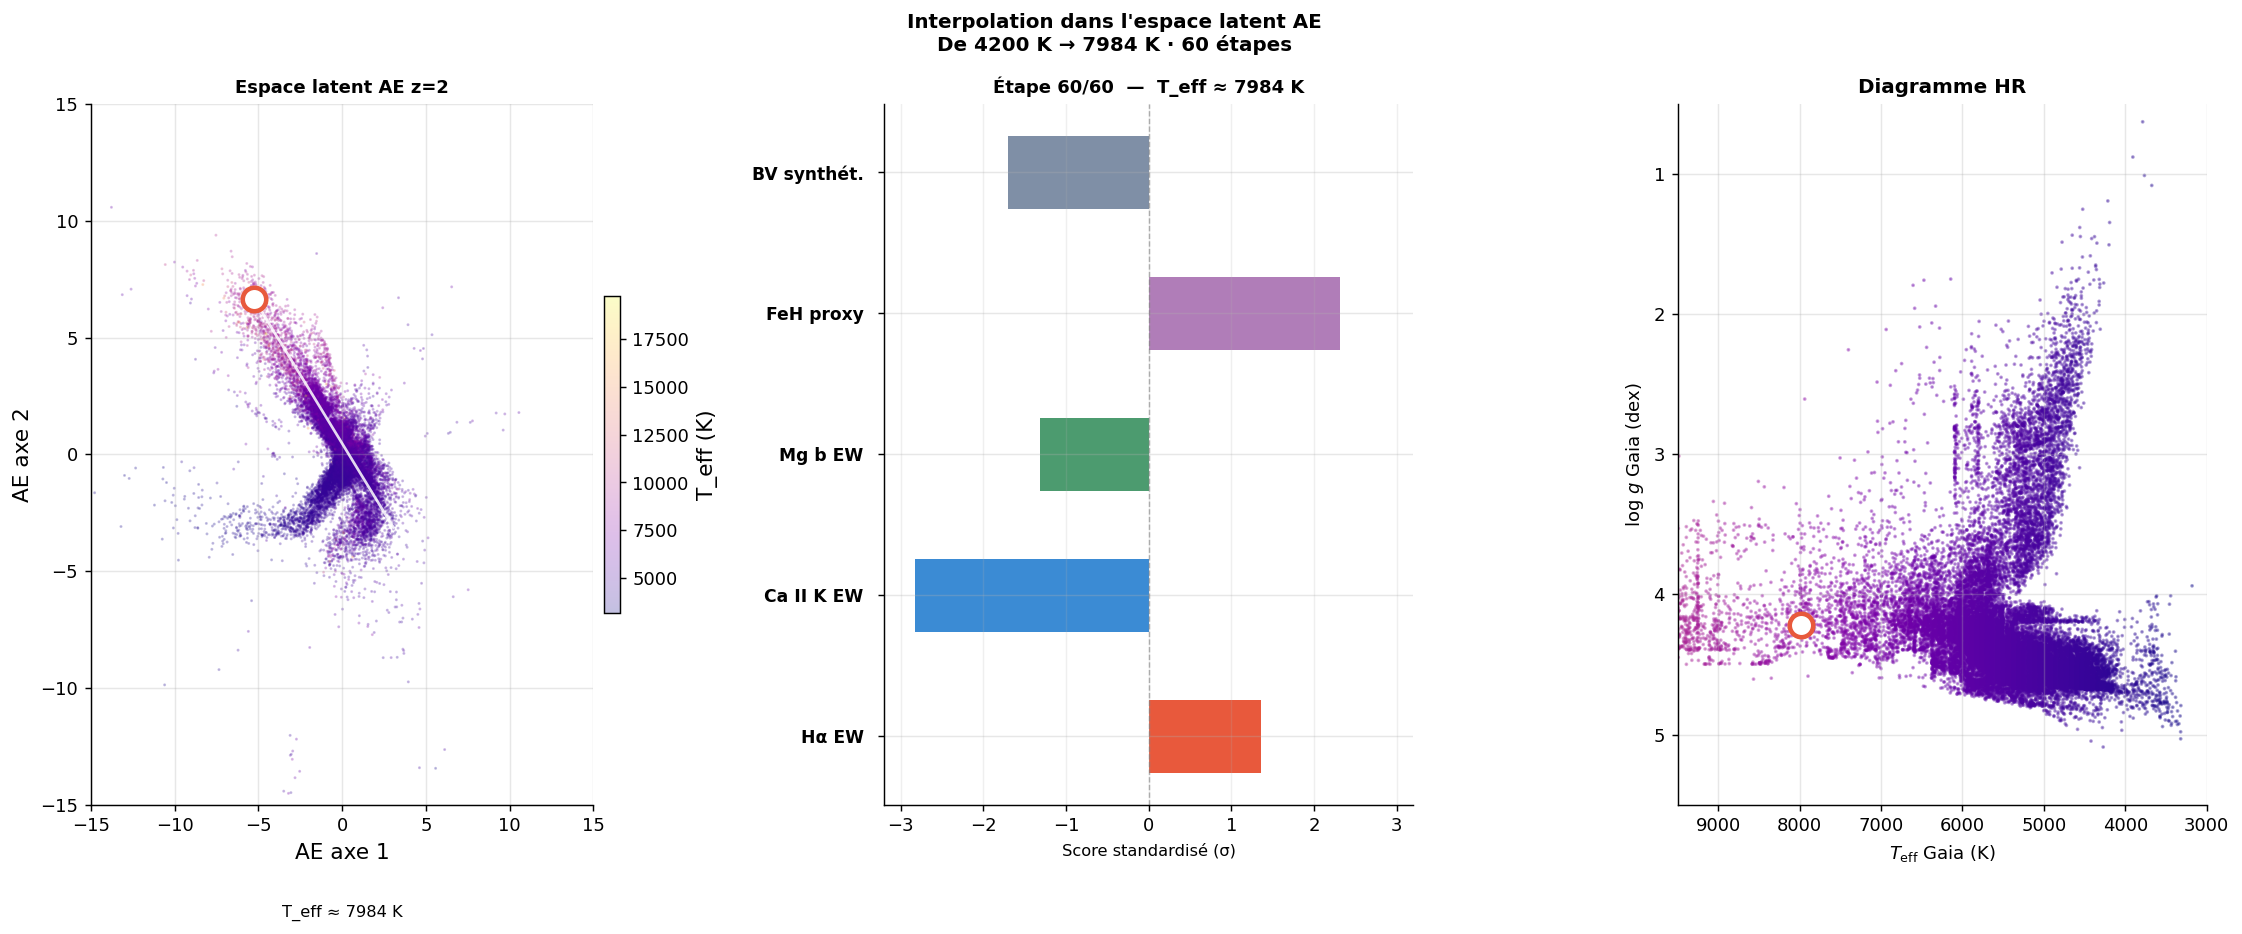

In [13]:
# NOTE : cette cellule génère un GIF matplotlib (N=60 frames, 15fps).
# La logique d'animation est conservée ici car elle requiert des
# variables locales (idx_cold/idx_hot) définies dans la cellule précédente.
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import warnings

N_FRAMES = 60
FPS_GIF  = 15
ALPHAS   = np.linspace(0, 1, N_FRAMES)

z_cold = Z_ae[idx_cold]
z_hot  = Z_ae[idx_hot]
teff_cold_val = meta['teff_gspphot'].iloc[idx_cold]
teff_hot_val  = meta['teff_gspphot'].iloc[idx_hot]

z_path  = np.array([(1-a)*z_cold + a*z_hot for a in ALPHAS])
X_path  = ae.decode(z_path)

KEY_FEATURES_OK = [
    (label, col, color, fam)
    for label, col, color, fam in [
        ('Hα EW','feature_Hα_eq_width','#E8593C','Balmer'),
        ('Ca II K EW','feature_CaIIK_eq_width','#3B8BD4','Calcium'),
        ('Mg b EW','feature_Mg_b_eq_width','#4C9B6F','Métaux'),
        ('FeH proxy','feature_FeH_proxy','#B07DB8','Métaux'),
        ('BV synthét.','feature_synthetic_BV','#7F8FA6','Continuum'),
    ]
    if col in feature_names
]
feat_indices = [feature_names.index(col) for _, col, _, _ in KEY_FEATURES_OK]
feat_labels  = [l for l, _, _, _ in KEY_FEATURES_OK]
feat_colors  = [c for _, _, c, _ in KEY_FEATURES_OK]
X_path_keys  = X_path[:, feat_indices]

teff_vals = meta['teff_gspphot'].values.astype(float)
valid_teff = np.isfinite(teff_vals)
logg_cold_v = float(meta['logg_gspphot'].iloc[idx_cold])
logg_hot_v  = float(meta['logg_gspphot'].iloc[idx_hot])
logg_vals   = meta['logg_gspphot'].values.astype(float)
valid_hr    = valid_teff & np.isfinite(logg_vals)

fig = plt.figure(figsize=(21, 7), dpi=130)
gs  = gridspec.GridSpec(1, 3, width_ratios=[1.4, 1.4, 1.4], wspace=0.50)
ax_lat  = fig.add_subplot(gs[0])
ax_feat = fig.add_subplot(gs[1])
ax_hr   = fig.add_subplot(gs[2])

sc = ax_lat.scatter(Z_ae[valid_teff,0], Z_ae[valid_teff,1],
    c=teff_vals[valid_teff], cmap='plasma', s=0.4, alpha=0.25, rasterized=True)
ax_lat.plot(z_path[:,0], z_path[:,1], 'w-', lw=1.5, alpha=0.85, zorder=3)
dot_lat, = ax_lat.plot([], [], 'o', color='white', ms=13, mec='#E8593C', mew=2.5, zorder=4)
plt.colorbar(sc, ax=ax_lat, label='T_eff (K)', fraction=0.03, pad=0.02)
ax_lat.set_xlabel('AE axe 1'); ax_lat.set_ylabel('AE axe 2')
ax_lat.set_title('Espace latent AE z=2', fontsize=10, fontweight='bold')
ax_lat.set_xlim(-15, 15)
ax_lat.set_ylim(-15, 15)
title_lat = ax_lat.text(0.5, -0.16, '', transform=ax_lat.transAxes, ha='center', fontsize=9)

n_keys = len(feat_labels)
y_pos  = np.arange(n_keys)
bars = ax_feat.barh(y_pos, np.zeros(n_keys), color=feat_colors, height=0.52,
                     edgecolor='none', linewidth=0)
ax_feat.set_yticks(y_pos)
ax_feat.set_yticklabels(feat_labels, fontsize=9.5, fontweight='bold')
ax_feat.set_xlim(-3.2, 3.2); ax_feat.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax_feat.tick_params(axis='y', pad=8)
ax_feat.set_xlabel('Score standardisé (σ)', fontsize=9); ax_feat.grid(axis='x', alpha=0.2)
title_feat = ax_feat.set_title('', fontsize=10, fontweight='bold')

ax_hr.scatter(teff_vals[valid_hr], logg_vals[valid_hr], c=teff_vals[valid_hr],
    cmap='plasma', s=1.2, alpha=0.35, rasterized=True)
ax_hr.set_xlim(9500, 3000); ax_hr.set_ylim(5.5, 0.5)
ax_hr.set_xlabel(r'$T_{\rm eff}$ Gaia (K)', fontsize=10)
ax_hr.set_ylabel(r'$\log\,g$ Gaia (dex)', fontsize=10)
ax_hr.set_title('Diagramme HR', fontsize=11, fontweight='bold')
dot_hr, = ax_hr.plot([], [], 'o', color='white', ms=13, mec='#E8593C', mew=2.5, zorder=4)

fig.suptitle(f'Interpolation dans l\'espace latent AE\n'
             f'De {teff_cold_val:.0f} K → {teff_hot_val:.0f} K · {N_FRAMES} étapes',
             fontsize=11, fontweight='bold', y=0.98)

def update(frame):
    a = ALPHAS[frame]
    teff_est = (1-a)*float(teff_cold_val) + a*float(teff_hot_val)
    logg_est = (1-a)*logg_cold_v + a*logg_hot_v
    dot_lat.set_data([z_path[frame, 0]], [z_path[frame, 1]])
    title_lat.set_text(f'T_eff ≈ {teff_est:.0f} K')
    for bar, v in zip(bars, X_path_keys[frame]): bar.set_width(v)
    title_feat.set_text(f'Étape {frame+1}/{N_FRAMES}  —  T_eff ≈ {teff_est:.0f} K')
    dot_hr.set_data([teff_est], [logg_est])
    return [dot_lat, title_lat, *bars, title_feat, dot_hr]

ani = animation.FuncAnimation(fig, update, frames=N_FRAMES,
    interval=1000//FPS_GIF, blit=True, repeat=True)

gif_path = FIGURES_DIR / 'ae_latent_animation.gif'
print(f'Génération du GIF ({N_FRAMES} frames, {FPS_GIF} fps)...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ani.save(str(gif_path), writer='pillow', fps=FPS_GIF, dpi=100,
         savefig_kwargs={'bbox_inches': None})
print(f'✓ GIF sauvegardé : {gif_path}')
plt.tight_layout(); plt.show()

<a id="anim-slider"></a>

### 5.2.1 · Version interactive — Plotly slider

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.12), rgba(90,42,94,0.12));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 12px 14px;
    margin-bottom: 10px;
">
La version Plotly produit un HTML interactif : un <strong>slider</strong> permet de naviguer manuellement à travers les 60 étapes de l'interpolation. Idéal pour la présentation au Musée de la Civilisation — on peut s'arrêter à mi-chemin, zoomer, et interagir avec le public.
</div>

In [ ]:
# Note : cellule auto-contenue car elle utilise les variables de la cellule
# précédente (z_path, X_path_keys, ALPHAS, teff_cold_val, teff_hot_val).
try:
    import plotly.graph_objects as go
    _PLOTLY_ANIM = True
except ImportError:
    print('⚠  Plotly non installé → pip install plotly')
    _PLOTLY_ANIM = False

if _PLOTLY_ANIM:
    N_BG   = min(15_000, len(Z_ae))
    rng_p  = np.random.default_rng(42)
    idx_bg = rng_p.choice(len(Z_ae), N_BG, replace=False)
    teff_bg = meta['teff_gspphot'].values[idx_bg]
    valid_bg = np.isfinite(teff_bg)
    Z_bg = Z_ae[idx_bg][valid_bg]
    T_bg = teff_bg[valid_bg]
    t_min, t_max = float(np.percentile(T_bg, 2)), float(np.percentile(T_bg, 98))

    fig_slider = go.Figure()
    fig_slider.add_trace(go.Scatter(
        x=Z_bg[:,0].tolist(), y=Z_bg[:,1].tolist(), mode='markers',
        marker=dict(size=2, opacity=0.3, color=T_bg.tolist(),
                    colorscale='Plasma', cmin=t_min, cmax=t_max,
                    colorbar=dict(title='T_eff (K)', x=0.48)),
        hoverinfo='skip'))
    fig_slider.add_trace(go.Scatter(
        x=z_path[:,0].tolist(), y=z_path[:,1].tolist(),
        mode='lines', line=dict(color='white', width=2, dash='dot'), hoverinfo='skip'))
    fig_slider.add_trace(go.Scatter(
        x=[z_path[0,0]], y=[z_path[0,1]], mode='markers',
        marker=dict(size=14, color='#E8593C', line=dict(color='white', width=2))))
    fig_slider.add_trace(go.Bar(
        x=X_path_keys[0].tolist(), y=feat_labels, orientation='h',
        marker_color=feat_colors, xaxis='x2', yaxis='y2', showlegend=False))

    frames_s = []
    for fi in range(N_FRAMES):
        a = ALPHAS[fi]
        teff_est = (1-a)*float(teff_cold_val) + a*float(teff_hot_val)
        frames_s.append(go.Frame(
            data=[go.Scatter(), go.Scatter(),
                  go.Scatter(x=[z_path[fi,0]], y=[z_path[fi,1]]),
                  go.Bar(x=X_path_keys[fi].tolist(), y=feat_labels)],
            name=str(fi),
            layout=go.Layout(title_text=(
                f'Interpolation latente AE — Étape {fi+1}/{N_FRAMES} · T_eff ≈ {teff_est:.0f} K'))))
    fig_slider.frames = frames_s

    fig_slider.update_layout(
        plot_bgcolor='#1A1A2E', paper_bgcolor='#16213E',
        font=dict(color='white', size=11),
        xaxis=dict(domain=[0, 0.45], title='AE axe 1', gridcolor='#333'),
        yaxis=dict(title='AE axe 2', gridcolor='#333'),
        xaxis2=dict(domain=[0.55, 1.0], title='Score standardisé (σ)',
                    range=[-3, 3], gridcolor='#333', zeroline=True, zerolinecolor='white'),
        yaxis2=dict(anchor='x2', gridcolor='#333'),
        updatemenus=[dict(type='buttons', showactive=False, x=0.5, y=1.08,
            buttons=[
                dict(label='▶ Play', method='animate',
                     args=[None, dict(frame=dict(duration=80, redraw=True), fromcurrent=True)]),
                dict(label='⏸ Pause', method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False))])])],
        sliders=[dict(active=0,
            currentvalue=dict(prefix='Étape : ', visible=True, xanchor='center'),
            steps=[dict(args=[[str(fi)], dict(frame=dict(duration=0, redraw=True), mode='immediate')],
                        label=str(fi+1), method='animate') for fi in range(N_FRAMES)])],
        height=600, width=1100, showlegend=False)

    slider_path = FIGURES_DIR / 'ae_interpolation_slider.html'
    fig_slider.write_html(str(slider_path), include_plotlyjs='cdn')
    print(f'✓ Slider interactif sauvegardé : {slider_path}')
    fig_slider.show()

<div style="
    background: linear-gradient(135deg, rgba(90,42,94,0.10), rgba(44,110,143,0.10));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 16px 18px;
    margin: 8px 0 14px 0;
">
<h4 style="margin: 0 0 10px 0; color: #2C6E8F;">Interprétation — La séquence de Harvard reconstruite</h4>
<p style="margin: 0 0 8px 0;">Si l'animation est physiquement cohérente, on devrait observer :</p>
<ul style="margin: 0 0 8px 0; padding-left: 18px; line-height: 1.6;">
  <li><strong>Hα, Hβ, Hδ</strong> croissants vers les types chauds (maximum vers A, F)</li>
  <li><strong>Ca II K &amp; H</strong> décroissants (absorbants dans les étoiles froides K, faibles dans A)</li>
  <li><strong>Mg b, FeH proxy</strong> décroissants (métallicité apparente liée à la gravité et la température)</li>
  <li><strong>BV synthétique</strong> décroissant (spectre se bleuit vers les étoiles chaudes)</li>
</ul>
<p style="margin: 0;">Tout écart à ces tendances signale soit une non-linéarité de l'AE (l'espace latent n'est pas parfaitement organisé selon la physique), soit une corrélation inattendue entre paramètres physiques — les deux sont scientifiquement intéressants.</p>
</div>

<a id="synthesis"></a>

<div style="background: linear-gradient(135deg, #5A2A5E 0%, #2C6E8F 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(90,42,94,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">6 · Synthèse comparative PCA / UMAP / Autoencodeur</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 0 0 10px 0;
">
La figure de synthèse 3x3 et le tableau quantitatif rassemblent les compromis entre interprétabilité, non-linéarité et reconstruction.
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-left: 5px solid #5A2A5E;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 0 0 10px 0;
">
<strong>6.0 Chargement des embeddings de référence (NB02)</strong>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #5A2A5E; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [ ]:
# Charge les embeddings UMAP/t-SNE produits dans NB02 pour fabriquer
# une comparaison tri-méthodes homogène (PCA, UMAP, AE).
embeddings_path = Path(paths["REPORTS_DIR"]) / "phy3500_embeddings.joblib"

if embeddings_path.exists():
    embeddings_output = joblib.load(embeddings_path)
    Z_umap = embeddings_output["Z_umap"]
    Z_tsne = embeddings_output.get("Z_tsne", None)
    print(f"✓ Embeddings chargés depuis {embeddings_path.name}")
    print(f"  Z_umap : {Z_umap.shape}")
    if Z_tsne is not None:
        print(f"  Z_tsne : {Z_tsne.shape}")
else:
    # Dégradation contrôlée : on garde le notebook exécutable même sans NB02.
    Z_umap = None
    Z_tsne = None
    print("⚠  Fichier phy3500_embeddings.joblib introuvable.")
    print("   → Lancer d'abord 02_umap_tsne.ipynb (section Sauvegarde, ancre #save).")

<a id="inference"></a>

<div style="background: linear-gradient(135deg, #2C6E8F 0%, #5A2A5E 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(44,110,143,0.30);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">6.1 · Inférence — tester un nouveau candidat</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.12), rgba(90,42,94,0.12));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 14px 16px;
    margin-bottom: 10px;
">
<p style="margin: 0 0 8px 0;">C'est ici que l'autoencodeur prouve sa <strong>supériorité sur t-SNE</strong> : il est paramétrique, il a appris une <em>fonction mathématique</em>, et peut donc projeter n'importe quel nouveau spectre sans recalcul. Un nouveau candidat passe par le pipeline en quelques millisecondes.</p>
<p style="margin: 0 0 8px 0;">La fonction <code>tester_candidat()</code> produit :</p>
<ol style="margin: 0; padding-left: 18px; line-height: 1.6;">
  <li>Les <strong>coordonnées latentes</strong> (z₁, z₂) → position sur la carte</li>
  <li>Le <strong>cluster HDBSCAN le plus proche</strong> → héritage des propriétés physiques</li>
  <li>La <strong>MSE de reconstruction</strong> → score d'anomalie avec verdict</li>
  <li>Une <strong>figure 3 panneaux</strong> : position sur l'embedding + profil features + jauge MSE</li>
</ol>
</div>

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #2C6E8F; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [ ]:
from dimred.autoencoder import tester_candidat

# Dé-standardisation pour obtenir des profils en unités physiques
# interprétables dans les figures d'inférence.
if hasattr(loader, 'scaler_') and loader.scaler_ is not None:
    X_raw_all = loader.scaler_.inverse_transform(X)
else:
    X_raw_all = X.copy()

teff_all = meta['teff_gspphot'].values.astype(float)
logg_all = meta['logg_gspphot'].values.astype(float)

# Trois profils astrophysiques représentatifs pour une démonstration
_CANDIDATS = [
    ('Étoile K géante',
     np.where(np.isfinite(teff_all) & (teff_all > 3800) & (teff_all < 5200)
              & np.isfinite(logg_all) & (logg_all < 3.0))[0]),
    ('Étoile A typique',
     np.where(np.isfinite(teff_all) & (teff_all > 8000) & (teff_all < 10000))[0]),
    ('Étoile G naine',
     np.where(np.isfinite(teff_all) & (teff_all > 5500) & (teff_all < 6200)
              & np.isfinite(logg_all) & (logg_all > 4.0))[0]),
]

# Le voisinage de cluster est optionnel selon l'état de la session.
_cluster_avail = 'cluster_labels' in dir() and cluster_labels is not None
_teff_for_cand = meta['teff_gspphot'].values.astype(float)

for _label, _candidates in _CANDIDATS:
    if len(_candidates) == 0:
        print(f'⚠  Aucun candidat trouvé pour : {_label}')
        continue
    _idx = _candidates[0]
    _result = tester_candidat(
        x_raw=X_raw_all[_idx],
        ae_model=ae,
        loader_ref=loader,
        feature_names_ref=feature_names,
        Z_train=Z_ae,
        cluster_labels_train=cluster_labels if _cluster_avail else None,
        teff_train=_teff_for_cand,
        label=_label,
        save_path=FIGURES_DIR / f'ae_candidat_{_label}.png',
    )
    print(f'{_label} — MSE={_result["mse"]:.4f} | Cluster={_result["cluster"]} | {_result["verdict"]}')
    print()

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.12), rgba(90,42,94,0.12));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 12px 14px;
    margin: 6px 0 12px 0;
">
<h4 style="margin: 0 0 8px 0; color: #2C6E8F;">Conclusion — L'autoencodeur comme outil d'analyse spectroscopique</h4>
<p style="margin: 0 0 6px 0;">La fonction <code>tester_candidat()</code> peut être appelée sur n'importe quel spectre du futur catalogue LAMOST DR6, ou même sur des spectres d'autres surveys (SDSS, GALAH) après adaptation du pipeline de features. C'est la preuve que l'AE n'a pas <em>mémorisé</em> les données — il a appris une <strong>représentation générale</strong> de la physique spectrale stellaire.</p>
<p style="margin: 0;">Pour un usage en production, on chargerait <code>ae_latent2.pt</code> et <code>pca_analyzer.joblib</code>, et le pipeline complet (features → StandardScaler → encode → cluster assignment + MSE) s'exécute en &lt;1ms par spectre — adapté à des catalogues de millions d'objets.</p>
</div>

<a id="synthesis-grid"></a>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-left: 5px solid #5A2A5E;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 8px 0;
">
<strong>6.2 Figure de synthèse 3x3 - PCA / UMAP / Autoencodeur</strong><br>
Grille comparative : lignes = méthodes, colonnes = colorations physiques.
</div>

In [ ]:
# Figure 3x3 de synthèse: compare la géométrie des embeddings
# selon la méthode et plusieurs colorations physiques.
fig = viz.plot_synthesis_grid(
    Z_ae=Z_ae,
    y=y,
    meta=meta,
    scores_pca=scores_pca,
    Z_umap=Z_umap if 'Z_umap' in dir() else None,
    save_path=FIGURES_DIR / 'synthesis_pca_umap_ae.png',
)
plt.show()

<a id="synthesis-table"></a>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #E5D8EC;
    border-left: 5px solid #5A2A5E;
    border-radius: 8px;
    padding: 10px 12px;
    margin: 8px 0;
">
<strong>6.3 Tableau comparatif quantitatif</strong><br>
Corrélations de température, erreur de reconstruction et propriétés qualitatives par méthode.
</div>

In [ ]:
# Tableau de comparaison compact : corrélation thermique et propriétés
# méthodologiques de chaque approche.
teff_vals  = meta['teff_gspphot'].values.astype(float)
teff_valid = np.isfinite(teff_vals)

def _r(Z_m, axis=0):
    # Corrélation de rang robuste aux relations non linéaires monotones.
    if Z_m is None: return float('nan')
    r, _ = spearmanr(Z_m[teff_valid, axis], teff_vals[teff_valid])
    return r

results = {}
results['PCA (PC1/PC2)'] = {
    'ρ(axe 1, T_eff)':   f'{_r(scores_pca):+.3f}',
    'MSE recon. (2 dim)': f'{float(pca.reconstruction_error(X, n_components=2).mean()):.5f}',
    'Paramétrique': 'Oui', 'Non-linéaire': 'Non', 'Interprétable': 'Oui (loadings)',
}
results['Autoencodeur (z=2)'] = {
    'ρ(axe 1, T_eff)':   f'{_r(Z_ae):+.3f}',
    'MSE recon. (2 dim)': f'{float(ae.reconstruction_mse(X)):.5f}',
    'Paramétrique': 'Oui', 'Non-linéaire': 'Oui', 'Interprétable': 'Partielle',
}
if 'Z_umap' in dir() and Z_umap is not None:
    results['UMAP'] = {
        'ρ(axe 1, T_eff)':   f'{_r(Z_umap):+.3f}',
        'MSE recon. (2 dim)': 'N/A',
        'Paramétrique': 'Oui (partiel)', 'Non-linéaire': 'Oui', 'Interprétable': 'Non',
    }

df_summary = pd.DataFrame(results).T
print('\n' + '='*65)
print('  RÉSUMÉ — NB03 : Comparaison PCA / UMAP / Autoencodeur')
print('='*65)
print(df_summary.to_string())
print('='*65)
print(f'\n  Temps entraînement AE : {ae.fit_time_:.1f} s')
print(f'  Best val_loss         : {min(ae.history_["val_loss"]):.6f}')

<a id="save"></a>

<div style="background: linear-gradient(135deg, #2C6E8F 0%, #5A2A5E 100%); padding: 16px 22px; border-radius: 10px; margin: 16px 0 10px 0; box-shadow: 0 6px 18px rgba(44,110,143,0.25);">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 1px;">7 · Sauvegarde des sorties et rapports de run</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(44,110,143,0.10), rgba(90,42,94,0.10));
    border-left: 6px solid #2C6E8F;
    border-radius: 10px;
    padding: 14px 16px;
    margin: 0 0 10px 0;
">
Cette section enregistre automatiquement les artefacts du run (joblib, JSON, TXT), avec un fichier horodaté et une version latest.
</div>

### Pourquoi c’est important
- Traçabilité complète des hyperparamètres, métriques et figures.
- Réutilisation directe des artefacts dans les notebooks suivants et le rapport.
- Reproductibilité stricte des résultats expérimentaux.

<div style="text-align: right; margin: 0 0 10px 0;">
  <a href="#toc" style="color: #2C6E8F; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

In [ ]:
from dimred.run_reporter import save_autoencoder_run

# Export centralisé des artefacts: métriques, embeddings, figures et contexte
# expérimental pour assurer traçabilité et reproductibilité.
result = save_autoencoder_run(
    ae=ae,
    X=X,
    y=y,
    meta=meta,
    feature_names=feature_names,
    paths=paths,
    FEATURES_PATH=FEATURES_PATH if "FEATURES_PATH" in dir() else None,
    CATALOG_PATH=CATALOG_PATH   if "CATALOG_PATH"  in dir() else None,
    FIGURES_DIR=FIGURES_DIR,
    MODELS_DIR=MODELS_DIR if "MODELS_DIR" in dir() else None,
    ae_model_path=ae_model_path if "ae_model_path" in dir() else None,
    # Variables optionnelles
    Z_ae=Z_ae       if "Z_ae"       in dir() else None,
    X_recon=X_recon if "X_recon"    in dir() else None,
    history=history if "history"    in dir() else None,
    comparison_df=comparison_df if "comparison_df" in dir() else None,
    summary_df=summary          if "summary"       in dir() else None,
    df_summary=df_summary       if "df_summary"    in dir() else None,
    scores_pca=scores_pca       if "scores_pca"    in dir() else None,
    pca=pca                     if "pca"           in dir() else None,
    n_pcs_95=n_pcs_95           if "n_pcs_95"      in dir() else None,
    Z_umap=Z_umap   if "Z_umap" in dir() else None,
    Z_tsne=Z_tsne   if "Z_tsne" in dir() else None,
    Z_interp=Z_interp if "Z_interp" in dir() else None,
    X_interp=X_interp if "X_interp" in dir() else None,
    idx_cold=idx_cold   if "idx_cold"   in dir() else None,
    idx_hot=idx_hot     if "idx_hot"    in dir() else None,
    teff_cold=teff_cold if "teff_cold"  in dir() else None,
    teff_hot=teff_hot   if "teff_hot"   in dir() else None,
    corr_pca=corr_pca   if "corr_pca"   in dir() else None,
)

print(result["summary"])

<div style="
    background: linear-gradient(135deg, #5A2A5E 0%, #2C6E8F 100%);
    padding: 16px 20px;
    border-radius: 10px;
    margin: 18px 0 10px 0;
    box-shadow: 0 6px 18px rgba(90,42,94,0.25);
">
  <h2 style="color: white; margin: 0; font-weight: 400; letter-spacing: 0.8px;">Références scientifiques et techniques</h2>
</div>

### Fondements autoencodeur et apprentissage profond
1. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature, 323, 533-536. (article fondateur de la rétropropagation).
2. Hinton, G. E., & Salakhutdinov, R. R. (2006). *Reducing the dimensionality of data with neural networks*. Science, 313(5786), 504-507. (autoencodeurs pour réduction de dimension).
3. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. (théorie générale des réseaux profonds, régularisation, optimisation).

### Réduction de dimension de référence
4. Jolliffe, I. T., & Cadima, J. (2016). *Principal component analysis: a review and recent developments*. Phil. Trans. A, 374:20150202. (cadre théorique PCA).
5. McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. arXiv:1802.03426. (comparaison conceptuelle avec embeddings non linéaires).

### Corrélation de rang et interprétation physique
6. Spearman, C. (1904). *The proof and measurement of association between two things*. American Journal of Psychology, 15(1), 72-101. (définition de rho de Spearman).

### Contexte astrophysique des données
7. Gaia Collaboration (2023). *Gaia Data Release 3: Summary of the content and survey properties*. Astronomy & Astrophysics, 674, A1.
8. Luo, A.-L., et al. (2019). *The LAMOST DR5 release*. Research in Astronomy and Astrophysics.

### Implémentation Python
9. PyTorch developers. *PyTorch documentation*. https://pytorch.org/docs/stable/
10. scikit-learn developers. *PCA documentation*. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 8px;
    padding: 10px 12px;
    margin-top: 12px;
">
Ces références couvrent les briques mobilisées dans ce notebook : apprentissage latent non linéaire, comparaison avec méthodes de réduction de dimension, validation statistique et contexte astrophysique.
</div>

<a id="conclusion"></a>

<div style="
    background: linear-gradient(135deg, #2D1E2F 0%, #5A2A5E 50%, #2C6E8F 100%);
    padding: 18px 22px;
    border-radius: 12px;
    margin: 18px 0 12px 0;
    box-shadow: 0 8px 24px rgba(45,30,47,0.30);
">
  <h2 style="color: white; margin: 0; font-weight: 350; letter-spacing: 1px;">Résumé final (run 20260405T220839Z)</h2>
</div>

<div style="
    background: linear-gradient(135deg, rgba(52, 94, 133, 0.18), rgba(89, 122, 157, 0.14));
    border: 1px solid #D4E3EC;
    border-radius: 10px;
    padding: 12px 14px;
    margin-bottom: 12px;
">
Tableau complété à partir de <code>data/reports/runs/phy3500_autoencoder/phy3500_autoencoder_run_20260405T220839Z.json</code>.
</div>

| Analyse | Résultat clé (run 20260405T220839Z) |
|---------|--------------------------------------|
| Échantillon | 43 019 objets, 183 features standardisées |
| Entraînement AE | 143.67 s, 145 epochs, best val_loss = 0.54808 |
| Reconstruction AE (z=2) | MSE globale = 0.48910 |
| Référence PCA (2 composantes) | MSE = 0.69627 |
| Référence PCA (n=51, 95% var) | MSE = 0.19624 |
| Corrélation AE axe 2 - T_eff | rho = +0.793 (gradient thermique fort) |
| Corrélation AE axe 2 - BP-RP | rho = -0.770 (cohérence couleur-température) |
| Interpolation latente froide-chaude | distance = 11.443 ; 4199.6 K -> 7984.0 K |

### Lecture scientifique
- À 2 dimensions, l’autoencodeur non linéaire reconstruit mieux que PCA-2 (0.489 vs 0.696), ce qui confirme l’intérêt d’un modèle non linéaire sous forte contrainte dimensionnelle.
- PCA avec davantage de composantes reste naturellement meilleur en erreur pure (MSE 0.196 à 51 composantes), ce qui est attendu car la capacité de reconstruction augmente avec la dimension.
- Dans ce run, le gradient thermique est surtout porté par l’axe latent 2 (rho +0.793 avec T_eff), ce qui illustre la liberté de rotation des axes latents en autoencodeur.
- Les classes minoritaires (GALAXY, QSO) présentent des erreurs bien plus élevées que STAR, en partie à cause du déséquilibre de classes.

### Recommandation pipeline
Pour la modélisation supervisée principale, les features physiques (ou PCA interprétable) restent la base la plus robuste. L’autoencodeur est particulièrement pertinent pour l’exploration non supervisée, la continuité latente et la détection d’objets atypiques.

<div style="text-align: right; margin-top: 10px;">
  <a href="#toc" style="color: #5A2A5E; text-decoration: none; font-size: 12px;">Retour à la table des matières</a>
</div>

## Conclusions

### Ce que chaque méthode apporte

| Critère | PCA | UMAP | Autoencodeur |
|---------|-----|------|--------------|
| Linéarité | Linéaire | Non-linéaire | Non-linéaire |
| Paramétrique (transform nouveaux points) | ✓ | ✓ (partiel) | ✓ |
| Erreur de reconstruction (2 dims) | *voir tableau* | N/A | *voir tableau* |
| Interprétabilité des axes | ✓✓ (loadings physiques) | ✗ | ✗ |
| Temps d'exécution | < 1 s | *voir §2* | *voir §2* |
| Stabilité | ✓✓ (déterministe) | *voir stabilité* | Variable |

### Observations physiques

- **PC1** corrèle fortement avec T_eff (température) : la PCA retrouve
  la séquence principale de Hertzsprung-Russell sans supervision.
- **UMAP** révèle des sous-structures discrètes (clusters) invisibles
  en PCA, témoignant de non-linéarités dans l'espace spectral.
- **L'autoencodeur** compresse vers un espace latent continu (validé
  par l'interpolation §5) mais ses axes n'ont pas d'interprétation
  physique directe contrairement aux loadings de la PCA.

### Recommandation pour le pipeline AstroSpectro principal

Pour la **classification XGBoost**, les features physiques directes (V2)
restent préférables : plus interprétables, déterministes, et prouvées
efficaces à 84 %+. La réduction de dimension est plus pertinente pour
l'**exploration non supervisée** et la **détection d'anomalies**.

### Lien avec PHY-3500

Ce notebook illustre le spectre des méthodes numériques enseignées :
- PCA → décomposition spectrale (valeurs propres, SVD, NR chap. 11)
- UMAP → graphes de voisinage, optimisation stochastique
- Autoencodeur → rétropropagation, descente de gradient, régularisation